In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

legend_img = cv2.imread("Images/NDVI_legend.png")
feild_img = cv2.imread("Images/NDVI_rotated_cropped.tif", cv2.IMREAD_UNCHANGED)

In [2]:
legend_img_dims = legend_img.shape[0:2]
feild_img_dims = feild_img.shape[0:2]

print(f"Legend Dimensions: {legend_img_dims}\nFeild Dimensions: {feild_img_dims}")

Legend Dimensions: (116, 1000)
Feild Dimensions: (17653, 4798)


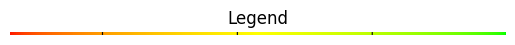

In [3]:
legend_img_rgb = cv2.cvtColor(legend_img, cv2.COLOR_BGR2RGB)

plt.imshow(legend_img_rgb[54:60 , 87:988])
plt.title("Legend")
plt.axis("off")
plt.show()

In [4]:
legend_slider_bounds = (57, (87,988))  #(y, (x_min, x_max)) slice we must take if we want to access the slider
legend_slider = legend_img[legend_slider_bounds[0], legend_slider_bounds[1][0]:legend_slider_bounds[1][1]]
legend_slider = legend_slider.astype(np.int32)

np.save("Data/legend_gradient.npy", legend_slider)
np.savetxt("Data/legend_gradient.csv", legend_slider, delimiter=',')

In [5]:
color_min, color_max = legend_slider[0], legend_slider[-1]
color_mid = np.clip(color_min + color_max, a_min=0, a_max=255)

NDVI_min = -0.078
NDVI_max = 0.925
NDVI_mid = float(np.round((NDVI_min + NDVI_max) * 0.5, 3))

print(color_min, color_mid, color_max)
print(NDVI_min, NDVI_mid, NDVI_max)

[  0  25 255] [  0 255 255] [  0 255   0]
-0.078 0.424 0.925


In [6]:
def color_to_ndvi(pixel_bgr):
    b, g, r = pixel_bgr

    if r >= g:       #then we interpolate using the G value
        t = max((g-color_min[1])/(255-color_min[1]), 0)
        NDVI_out = NDVI_min + t * (NDVI_mid - NDVI_min)
        return float(NDVI_out)
    
    if g > r:       #then we interpolate using the R value
        t = max((255-r)/(255-0), 0)
        NDVI_out = NDVI_mid + t * (NDVI_max - NDVI_mid)
        return float(NDVI_out)
    
    return np.nan

In [7]:
expected_ndvi_values = np.linspace(NDVI_min, NDVI_max, num=legend_slider.shape[0], endpoint=True)
calculated_ndvi_values = np.array([color_to_ndvi(pixel) for pixel in legend_slider])

mae = mean_absolute_error(expected_ndvi_values, calculated_ndvi_values)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 0.07752736849807565


In [8]:
feild_B, feild_G, feild_R = cv2.split(feild_img)
pixels = np.stack((feild_B, feild_G, feild_R), axis=-1)

ndvi_image = np.apply_along_axis(color_to_ndvi, axis=-1, arr=pixels)

In [10]:
cv2.imwrite("Images/NDVI_computed_image.png", (ndvi_image + -ndvi_image.min()) * 255 / (ndvi_image.max()-ndvi_image.min()))
np.save("Data/NDVI_feild.npy", ndvi_image)